# 08 · Discovery — which of the 41 features actually matter?

> ⏱️ **~35 min** &nbsp;·&nbsp; 🧭 **SOP:** Phase 5 · discovery &nbsp;·&nbsp; 🧩 **Feeds:** Phase 6 hypotheses → directly shapes MasterVP (VP levels), Monster (VP+vol), KenKem (trend)
>
> 🎯 **Goal:** Rank features by real predictive power (MI + model importance), prune redundancy, and cluster regimes.
>
> 🔑 **The one thing to remember:** There is **no lone-feature magic edge** here. Volume-Profile distances + hour + direction (DI) lead — and only *together*, *conditioned on regime*.

## Notebook 08 in one breath

> **Where we are.** We have a labeled dataset of 41 features. Now the central question of the whole
> project: **which features carry signal about the future, which are redundant, and does the market
> split into regimes that behave differently?** This is the Python companion to the real Phase-5 code
> (`research/discovery/discover.py`), and we'll load its *actual saved results* alongside live demos.

**What you'll learn:**
1. **Mutual information** — catching *any* dependency, not just straight lines (recap from notebook 07).
2. **Model-based importance** (a gradient-boosted tree + the idea of **SHAP**) — letting a model rank
   features by how much they improve a real prediction.
3. **Redundancy / multicollinearity** — why "41 features" is really ~24, and why that matters.
4. **Regime clustering** (KMeans) — and reading an *honest negative result* correctly.

In [1]:
# --- Standard setup (run me first) -------------------------------------------------
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import duckdb                 # streams Parquet/CSV without loading it all into RAM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    """Walk up until we see the repo's pipeline/ + data/ — works from any sub-dir."""
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pipeline").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError("repo root (with pipeline/ and data/) not found above " + str(start))

ROOT = _find_root(Path.cwd())
DATA = ROOT / "data"
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `from pipeline import ...` works (the real Layer-1 code)
con  = duckdb.connect()       # one in-memory DuckDB connection we reuse all notebook

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

print("repo root :", ROOT)
print("data dir  :", DATA)

repo root : /Users/tokyotechies/Workspace/KEM/dquants
data dir  : /Users/tokyotechies/Workspace/KEM/dquants/data


In [2]:
DISC = ROOT / "research" / "discovery"          # the real Phase-5 artifacts live here
import matplotlib.image as mpimg

# Build the supervised dataset (features ⨝ labels) and a fast working sample.
feats = pd.read_parquet(DATA / "features" / "features_btcusd_M3.parquet")
labs  = pd.read_parquet(DATA / "labels"   / "labels_btcusd_M3.parquet")
df = feats.merge(labs, on="ts", how="inner")

label_cols   = ["fwd_ret_5","fwd_ret_10","fwd_ret_20","fwd_ret_60","hit_tp_before_sl"]
feature_cols = [c for c in df.select_dtypes("number").columns if c not in label_cols]
df = df.dropna(subset=feature_cols + ["fwd_ret_20","hit_tp_before_sl"]).reset_index(drop=True)
print(f"dataset: {df.shape[0]:,} usable rows × {len(feature_cols)} numeric features")

dataset: 424,229 usable rows × 41 numeric features


## Step 1 · Mutual information — a fair first ranking

Notebook 07 showed Pearson sees only straight lines. **Mutual information (MI)** measures *any*
dependency (it's 0 only if two variables are truly independent), so it's a fairer "does this feature
know anything about the future?" screen. Let's compute MI between each feature and `fwd_ret_20` on a
sample.

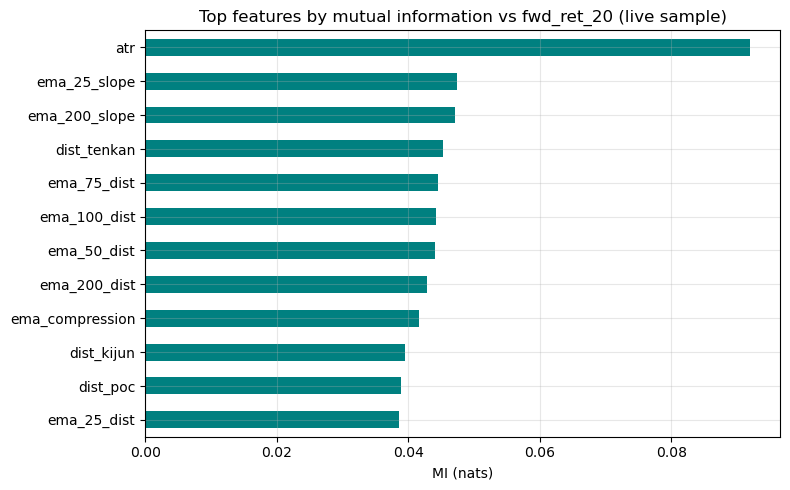

atr             0.0919
ema_25_slope    0.0474
ema_200_slope   0.0471
dist_tenkan     0.0453
ema_75_dist     0.0446
ema_100_dist    0.0443
ema_50_dist     0.0441
ema_200_dist    0.0429
dtype: float64

In [3]:
from sklearn.feature_selection import mutual_info_regression
samp = df.sample(40_000, random_state=0)
mi = mutual_info_regression(samp[feature_cols], samp["fwd_ret_20"], random_state=0)
mi_rank = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
ax = mi_rank.head(12).iloc[::-1].plot(kind="barh", figsize=(8,5), color="teal")
ax.set_title("Top features by mutual information vs fwd_ret_20 (live sample)"); ax.set_xlabel("MI (nats)")
plt.tight_layout(); plt.show()
mi_rank.head(8).round(4)

> 📘 **Concept — read the *magnitudes*, not just the order.** Those MI values are *tiny* (hundredths of
> a nat). MI has no fixed scale, but near-zero across the board is itself the message: **no feature is
> individually very informative** about the next move. That is the honest reality of liquid markets —
> and exactly why a profitable strategy needs *combinations* + *costs discipline*, not one magic line.

## Step 2 · Let a model rank them — gradient boosting + SHAP

A single-feature screen can miss features that only matter *in combination*. So we train a real model
to predict the trade outcome and ask which features it leaned on.

> 📘 **Concept — gradient-boosted trees & SHAP.** A gradient-boosted tree (LightGBM) builds many small
> decision trees that correct each other; it captures non-linear, interacting effects out of the box.
> **SHAP** values then fairly attribute each prediction to each feature (game-theoretic credit
> assignment), giving a robust importance ranking. We predict `hit_tp_before_sl` (+1 vs −1).

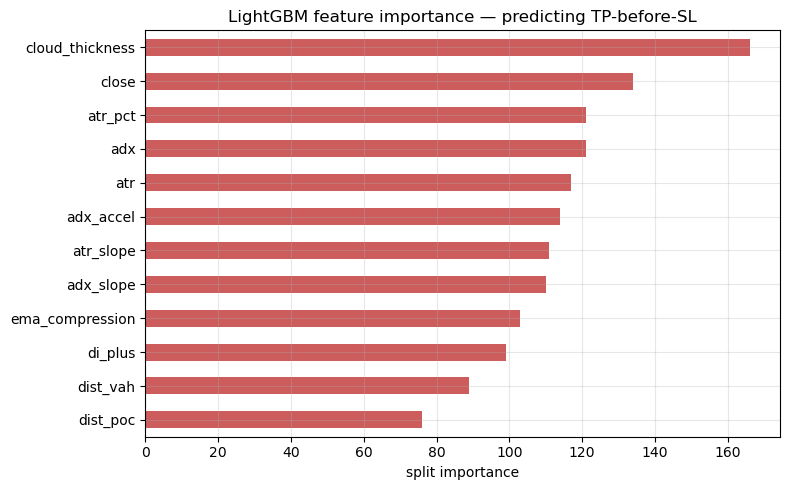

cloud_thickness    166
close              134
atr_pct            121
adx                121
atr                117
adx_accel          114
atr_slope          111
adx_slope          110
dtype: int32

In [4]:
import lightgbm as lgb
bin_df = df[df["hit_tp_before_sl"] != 0].copy()      # drop timeouts; classify TP(+1) vs SL(-1)
y = (bin_df["hit_tp_before_sl"] == 1).astype(int)
s = bin_df.sample(60_000, random_state=0)
ys = y.loc[s.index]
model = lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           subsample=0.8, num_leaves=31, n_jobs=-1, verbosity=-1)
model.fit(s[feature_cols], ys)
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
ax = imp.head(12).iloc[::-1].plot(kind="barh", figsize=(8,5), color="indianred")
ax.set_title("LightGBM feature importance — predicting TP-before-SL"); ax.set_xlabel("split importance")
plt.tight_layout(); plt.show()
imp.head(8)

## Step 3 · The project's *actual* Phase-5 verdict

The real discovery run (all years, full SHAP) saved its ranking to `research/discovery/`. Loading it
shows the same story our live demos hint at — and it's the authoritative input to strategy design.

In [5]:
drivers = pd.read_csv(DISC / "drivers_btcusd_M3.csv")
print("Top 10 drivers (real Phase-5 SHAP ranking, BTCUSD M3):")
drivers.head(10)[["feature","shap_importance","direction","mi_fwd_ret_20","stability"]]

Top 10 drivers (real Phase-5 SHAP ranking, BTCUSD M3):


,feature,shap_importance,direction,mi_fwd_ret_20,stability
0,dist_val,0.0236069,↑tp,0.0331294,stable-
1,hour,0.020359,↑tp,0.0217454,stable+
2,dist_poc,0.0199837,↓tp,0.0377307,stable-
3,dist_vah,0.0186574,↓tp,0.0434566,stable-
4,atr,0.0178459,↓tp,0.0928181,stable+
5,di_plus,0.0175657,↑tp,0.00381084,stable-
6,atr_pct,0.0163889,↑tp,0.0323905,stable+
7,rsi_21,0.0161757,↓tp,0.00345178,stable-
8,di_spread,0.0157208,↑tp,0.00363708,stable-
9,dow,0.0153741,↑tp,0.0270824,stable-


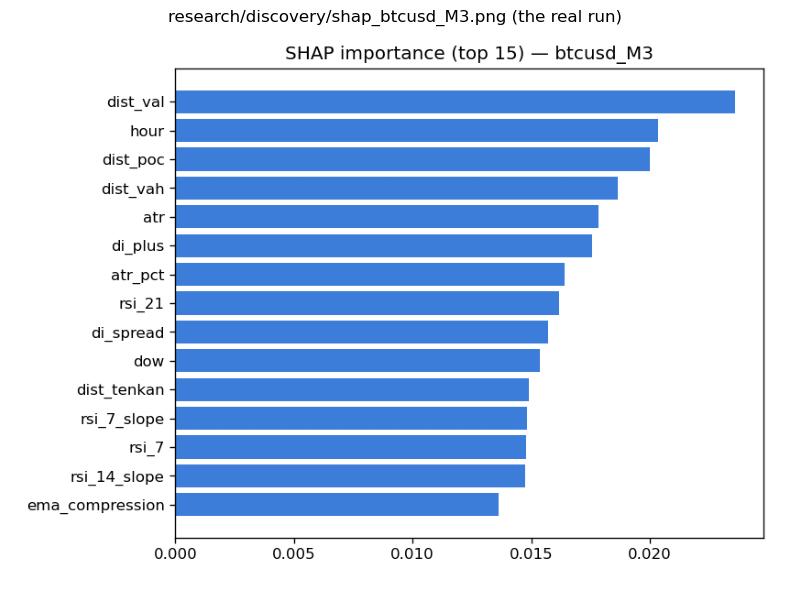

In [6]:
# The saved SHAP summary plot from the real run:
plt.figure(figsize=(9, 6))
plt.imshow(mpimg.imread(DISC / "shap_btcusd_M3.png")); plt.axis("off")
plt.title("research/discovery/shap_btcusd_M3.png (the real run)"); plt.tight_layout(); plt.show()

**The consistent headline (note it down):**
- **Volume-Profile distances dominate** — `dist_val`, `dist_poc`, `dist_vah` top the list. *This is why
  MasterVP and Monster are VP-centric strategies.*
- **`hour` is consistently important and sign-stable** across years.
- **Direction (`di_plus`/`di_minus`) beats RSI** — hence the ADX/DI regime gate.
- Every importance is *small* in absolute terms → the edge is faint and must be engineered carefully.

## Step 4 · Redundancy — "41 features" is really ~24

Many features are near-duplicates (adjacent EMAs are ~0.99 correlated, as you saw in notebook 03).
Feeding a model twenty colinear columns doesn't add twenty insights — it adds noise and fools naive
importance scores.

> 📘 **Concept — multicollinearity.** When features move together, the model can't tell which one
> "matters", importance gets split arbitrarily, and you fool yourself about what's driving results. The
> fix: cluster features by correlation and keep one representative per cluster. The real run did this
> and collapsed 41 → ~24 effective features.

In [7]:
import json
red = json.loads((DISC / "redundancy_btcusd_M3.json").read_text())
groups = red.get("linkage_groups", red) if isinstance(red, dict) else red
big = sorted(groups, key=len, reverse=True)
print(f"{len(feature_cols)} raw features collapse into {len(groups)} redundancy clusters.")
print(f"\nLargest cluster ({len(big[0])} near-redundant features — mostly the EMA ribbon + RSI levels):")
print(", ".join(big[0][:12]) + (" ..." if len(big[0])>12 else ""))

41 raw features collapse into 4 redundancy clusters.

Largest cluster (21 near-redundant features — mostly the EMA ribbon + RSI levels):
di_minus, di_plus, di_spread, dist_cloud, dist_kijun, dist_tenkan, ema_100_dist, ema_100_slope, ema_12_dist, ema_12_slope, ema_200_dist, ema_200_slope ...


## Step 5 · Regimes — does the market split into different "moods"?

Maybe no feature predicts *on average*, but signal hides inside specific **regimes** (calm vs trending
vs expanding). We cluster bars by a few descriptors (ADX, ATR-percentile, EMA-compression) with
**KMeans** and check each regime's TP-rate. Here's the real run's regime table:

In [8]:
reg = pd.read_csv(DISC / "regimes_summary_btcusd_M3.csv")
view = reg[["regime","bars","pct_of_bars","tp_rate","mean_fwd_ret_20","adx","atr_pct"]].copy()
view["tp_rate"] = view["tp_rate"].round(4); view["mean_fwd_ret_20"] = view["mean_fwd_ret_20"].round(6)
print("Base TP-rate across all bars ≈ 0.496\n")
view

Base TP-rate across all bars ≈ 0.496



,regime,bars,pct_of_bars,tp_rate,mean_fwd_ret_20,adx,atr_pct
0,Compression,158826,0.3744,0.491,-7e-06,19.751,0.171218
1,Reversal,113961,0.2686,0.4968,0.0001,19.5782,0.692619
2,Weak Trend,73821,0.174,0.4958,-8.1e-05,31.1878,0.588258
3,Strong Trend,56422,0.133,0.4921,5e-06,36.6561,0.682153
4,Expansion,21220,0.05,0.4872,0.000359,40.5243,0.875165


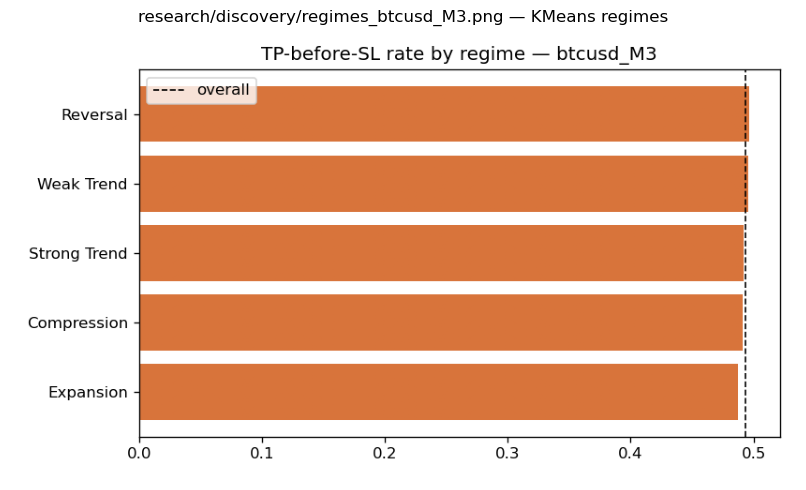

In [9]:
plt.figure(figsize=(9, 5))
plt.imshow(mpimg.imread(DISC / "regimes_btcusd_M3.png")); plt.axis("off")
plt.title("research/discovery/regimes_btcusd_M3.png — KMeans regimes"); plt.tight_layout(); plt.show()

> 🧠 **Read this honestly.** Every regime's `tp_rate` sits within ~0.01 of the 0.496 base rate — i.e.
> the symmetric 1×ATR barrier washes out almost all edge. **This is a real negative result, not a
> failure.** But look at `mean_fwd_ret_20`: the **Expansion** and **Reversal** regimes carry the only
> positive forward drift. The symmetric barrier *hides* it — which tells us precisely what to do next.

## Step 6 · So what does discovery actually tell the strategy builders?

This is where research becomes engineering. The Phase-5 verdict drives Phase-6 hypotheses:

1. **Symmetric barriers kill the edge → go asymmetric / directional.** Reward-to-risk > 1, take the side
   the trend favors. (Every edition uses RR-based targets, not symmetric ones.)
2. **Build around VP levels + hour/session + DI regime** — the features that actually ranked, *together*.
   → **MasterVP**: breakouts from prior-day VP levels, gated by ADX/DI. → **Monster**: adds multi-TF
   net-volume on top of VP. → **KenKem**: a trend menu (EMA alignment / Ichimoku) for the trending
   regimes.
3. **Condition on regime** — only trade breakouts when Strong-Trend/Expansion is present.
4. **Drop the 17 redundant features** before any modeling.

> 🧩 **The thread to the editions.** Notebooks 00–07 built and vetted the *evidence*; this notebook
> *ranks* it; notebook **10** shows how that evidence became the three concrete strategies and how we
> validate them. Discovery is the hinge between "data science" and "trading system".

## 🎯 Your turn

1. **MI vs model.** Compare your Step-1 MI top-10 with your Step-2 LightGBM top-10. Which features
   appear in *both*? Those are your most trustworthy signals.
2. **Asymmetric relabel.** Rebuild labels with `tp_mult=2, sl_mult=1` (notebook 04) and re-train the
   Step-2 model. Does any feature's importance jump? That's a hypothesis worth a backtest.
3. **One regime.** Filter `df` to the Expansion regime (high `atr_pct` & high `adx`) and recompute the
   TP-rate by `hour`. Anything above 0.52?
4. **Gold discovery.** None of this exists for XAU yet. Build XAU features+labels (notebooks 02–04) and
   run Step 1's MI ranking. Do VP distances lead for gold too?

➡️ **Next:** notebook **10** — how this whole journey became KenKem, MasterVP & Monster, and how we
prove an edge is real before risking a cent.